# Data Science in Healthcare 
## Data Analysis Task - summative assessment  


You have been given access to data on patients attending an acute medical unit (AMU). An AMU is a specialist ward in a hospital which cares for patients who have a rapid onset of severe symptoms, and who therefore prompt treatment. The data contains measurements taken from patients at various time points, alongside other sociodemographic and health data.

You are asked to predict which adult patients have a critical incident within 72 hours of admission to the AMU (`crit_72`).

Your classification model should be usable on admission to the AMU. 

The `Data Analysis Task: data` folder on the VLE contains three files:
- `training_data.csv` – details of a subset of patients, with `crit_72` disclosed
- `test_data.csv` – details of a subset of patients, with `crit_72` not disclosed
- `data_dictionary.gdoc` – the data dictionary for these data 

*Note: These data are based on real patient data but are synthetic*

You will need to pre-process the training and test datasets. You are asked to include a binary feature representing whether a patient has multimorbidity (`1 = multimorbidity`, `0 = no multimorbidity`), based on `num_diagnoses`. Convert `num_diagnoses` into a binary feature, using an appropriate threshold. Justify your choice. Ensure you have shown some consideration of sample size requirements. 

Once you have pre-processed the data, you are asked to do two data analysis tasks:

**1 - Build an ensemble model** 

- Use the training data to build an ensemble model to predict `crit_72` 
- Show evidence that you have considered multiple different types of ensemble model
- Optimise your ensemble models for balanced accuracy score

Based on your findings, choose **one** of your ensemble models to take forward as your final model 

- Plot the calibration curve of your chosen ensemble, and recalibrate the predicted probabilities using an appropriate method
- Provide some interpretation of your final model
- Use your final model to predict the class label for those individuals in `test_data.csv`. Save your predicted classes as `y_predict_ensemble`. These predictions will be compared to `y_test`, which you do *not* have access to. The performance of your final ensemble model on the test data will contribute to your mark for this question

**2 - Build a logistic regression model**

- Use the training data to build a logistic regression model to predict `crit_72` 
- Assess the balanced accuracy score
- Based on your findings, would you recommend using this model instead of your ensemble model? Provide a comment that explains your choice. You do *not* need to use your logistic regression model to predict the class label for those individuals in `test_data.csv`.


Ensure your final notebook is complete and runs without error. If you cannot get any component of your code to run, then comment it out and explain what you were trying to do.

Your code should be commented, and you should also include text sections in your notebook providing additional background information and any references needed to explain your code.

[The marking rubric for the Data Analysis Task is available here](https://docs.google.com/document/d/1XwlJmmi8_iAgTHdD7-3pltPMdJ0_0oQDxZi1YlVBusg/edit?usp=sharing)

When you have finished, download this notebook as an .ipynb format, and upload it to the submission point called `Data Analysis Task: submission point` on the VLE by the deadline. 

You do not need to upload any data. 

You must include a cover sheet with your submission - this is available in the Assessment folder of the VLE (`PGT Cover Sheet`). You should put the word count as 'not applicable' on the cover sheet for this assignment.

## Data Analysis

In [1]:
# reading in the training and test data
import pandas as pd
import numpy as np

train = pd.read_csv('training_data.csv')
test = pd.read_csv('test_data.csv')

In [2]:
# viewing first few rows of the training data
train.head()

,patient_id,abdominal,age,alcohol_dependent,alcohol_dependent_sr,arrival_mode,arrival_period,bmi,cardiac,chest_pain,...,meds_vitamins,num_diagnoses,num_prev_visits,nutrition,o2,pulse_1,pulse_2,sedation,triglycerides,vasopressors
0,54380870,0.0,40.0,0.0,0.0,0.0,1.0,24.379999,0.0,0.0,...,0.0,1.0,2.0,1.0,NaN,60.7,55.2,1.0,136.10001,1.0
1,99762057,0.0,53.0,1.0,1.0,0.0,1.0,24.629999,1.0,0.0,...,1.0,3.0,3.0,0.0,NaN,NaN,NaN,1.0,NaN,1.0
2,10969978,0.0,82.0,0.0,NaN,0.0,1.0,23.160000,1.0,0.0,...,0.0,2.0,10.0,1.0,NaN,77.8,69.3,0.0,129.30000,0.0
3,94206937,0.0,37.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,59462480,0.0,20.0,0.0,0.0,NaN,0.0,20.440001,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,75.3,72.0,1.0,NaN,0.0


In [3]:
# viewing last few rows of the training data
train.tail()

,patient_id,abdominal,age,alcohol_dependent,alcohol_dependent_sr,arrival_mode,arrival_period,bmi,cardiac,chest_pain,...,meds_vitamins,num_diagnoses,num_prev_visits,nutrition,o2,pulse_1,pulse_2,sedation,triglycerides,vasopressors
14995,47083269,NaN,NaN,1.0,0.0,1.0,1.0,NaN,1.0,NaN,...,NaN,NaN,2.0,NaN,24.0,64.3,57.3,NaN,158.70000,NaN
14996,57699515,0.0,49.0,NaN,0.0,0.0,1.0,27.440001,0.0,0.0,...,NaN,1.0,4.0,0.0,NaN,59.0,56.3,1.0,111.10000,1.0
14997,40993562,0.0,44.0,1.0,1.0,1.0,1.0,31.799999,0.0,0.0,...,0.0,0.0,5.0,1.0,NaN,54.1,51.9,1.0,193.89999,0.0
14998,93419264,0.0,63.0,0.0,0.0,0.0,1.0,23.320000,0.0,0.0,...,0.0,0.0,3.0,1.0,72.0,69.7,68.1,1.0,152.80000,0.0
14999,66609062,0.0,44.0,0.0,NaN,1.0,1.0,26.790001,1.0,0.0,...,0.0,3.0,8.0,0.0,NaN,66.1,57.4,1.0,NaN,0.0


In [4]:
# checking for duplicates in the training data
duplicates = train['patient_id'].duplicated()

train[duplicates]

,patient_id,abdominal,age,alcohol_dependent,alcohol_dependent_sr,arrival_mode,arrival_period,bmi,cardiac,chest_pain,...,meds_vitamins,num_diagnoses,num_prev_visits,nutrition,o2,pulse_1,pulse_2,sedation,triglycerides,vasopressors
6428,10969978,0.0,38.0,1.0,0.0,1.0,0.0,23.389999,0.0,0.0,...,0.0,1.0,4.0,1.0,NaN,68.7,62.3,0.0,NaN,0.0
14955,59462480,0.0,20.0,0.0,0.0,NaN,0.0,20.440001,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,75.3,72.0,1.0,NaN,0.0


In [5]:
# dropping duplicate patient_id's from the training data
train = train.drop_duplicates(subset='patient_id')

<Axes: >

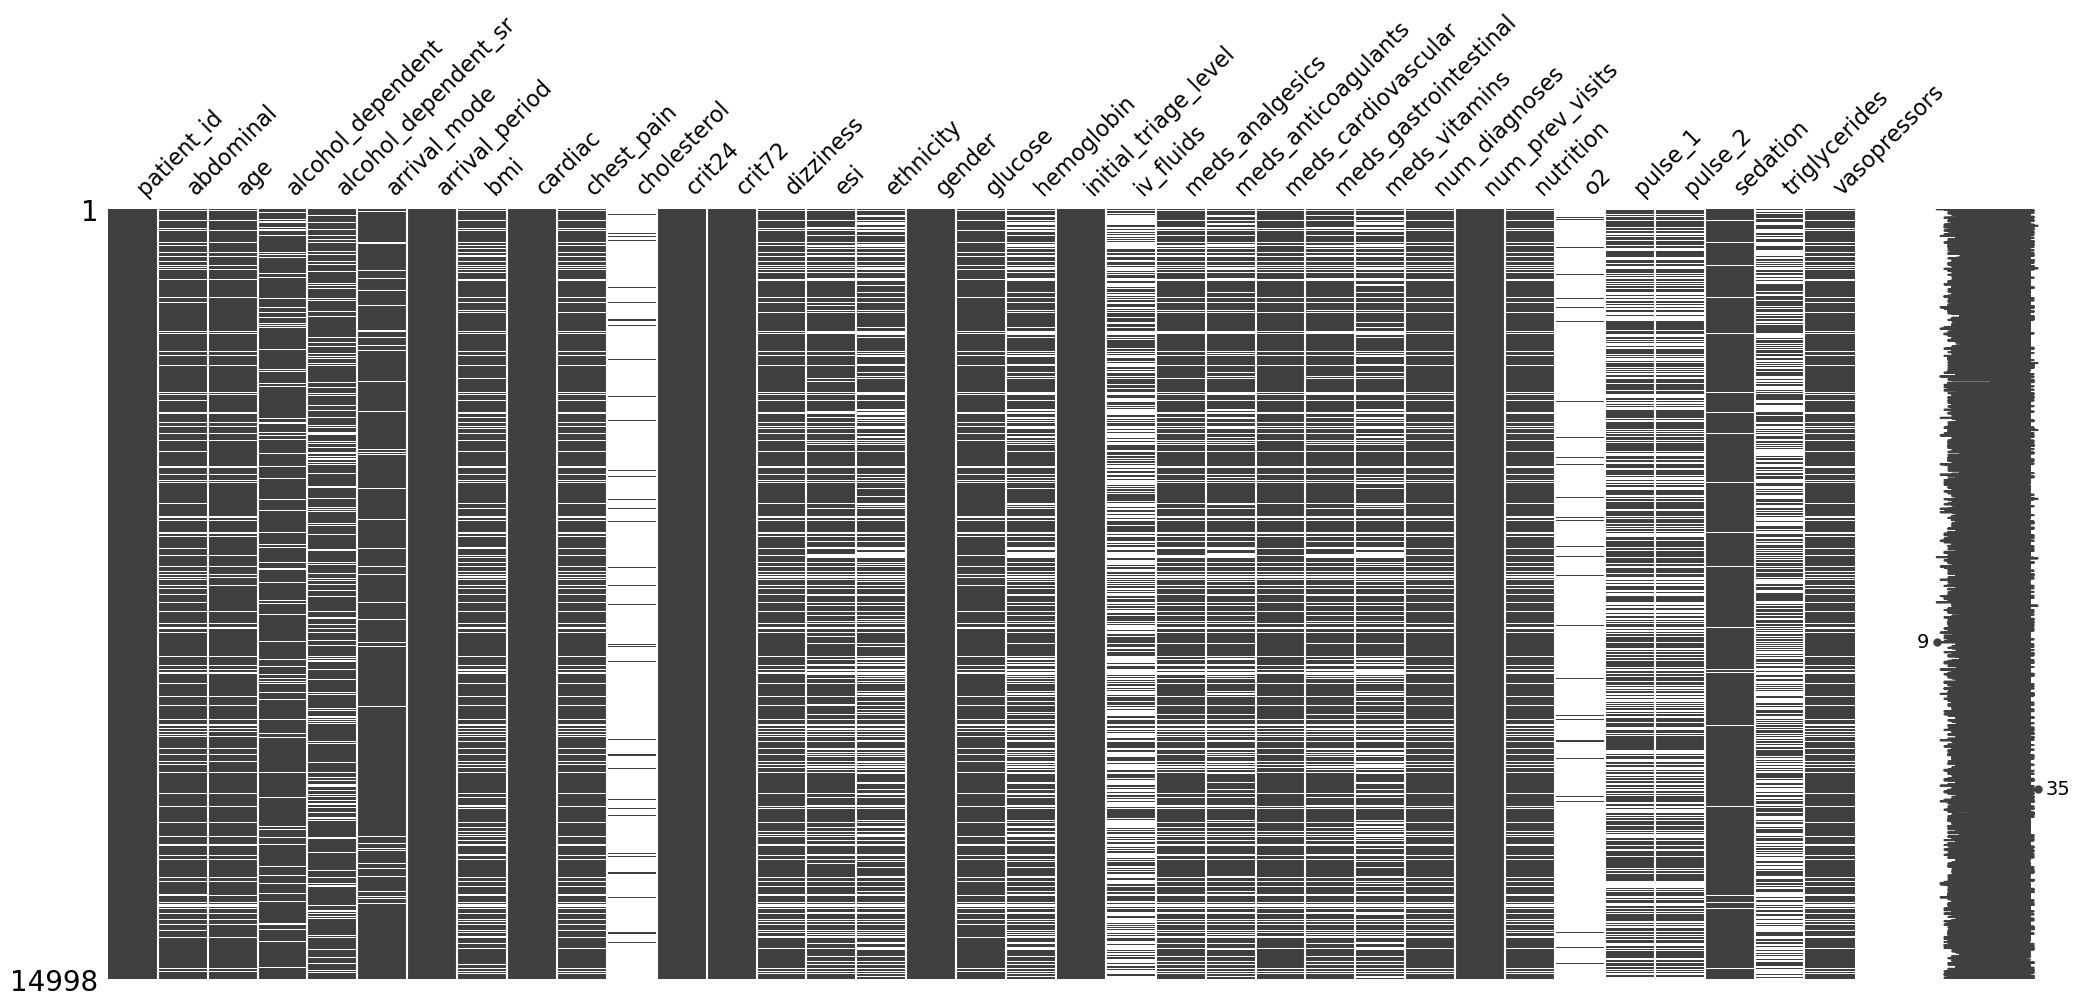

In [6]:
# checking missingness in the training data
import missingno as msno
msno.matrix(train)

array([[<Axes: title={'center': 'patient_id'}>,
        <Axes: title={'center': 'abdominal'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'alcohol_dependent'}>,
        <Axes: title={'center': 'alcohol_dependent_sr'}>,
        <Axes: title={'center': 'arrival_mode'}>],
       [<Axes: title={'center': 'arrival_period'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'cardiac'}>,
        <Axes: title={'center': 'chest_pain'}>,
        <Axes: title={'center': 'cholesterol'}>,
        <Axes: title={'center': 'crit24'}>],
       [<Axes: title={'center': 'crit72'}>,
        <Axes: title={'center': 'dizziness'}>,
        <Axes: title={'center': 'esi'}>,
        <Axes: title={'center': 'ethnicity'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'hemoglobin'}>],
       [<Axes: title={'center': 'initial_triage_level'}>,
        <Axes: title={'center': 'iv_fluids'}>,
        <Axes: title={'center': 'meds_anal

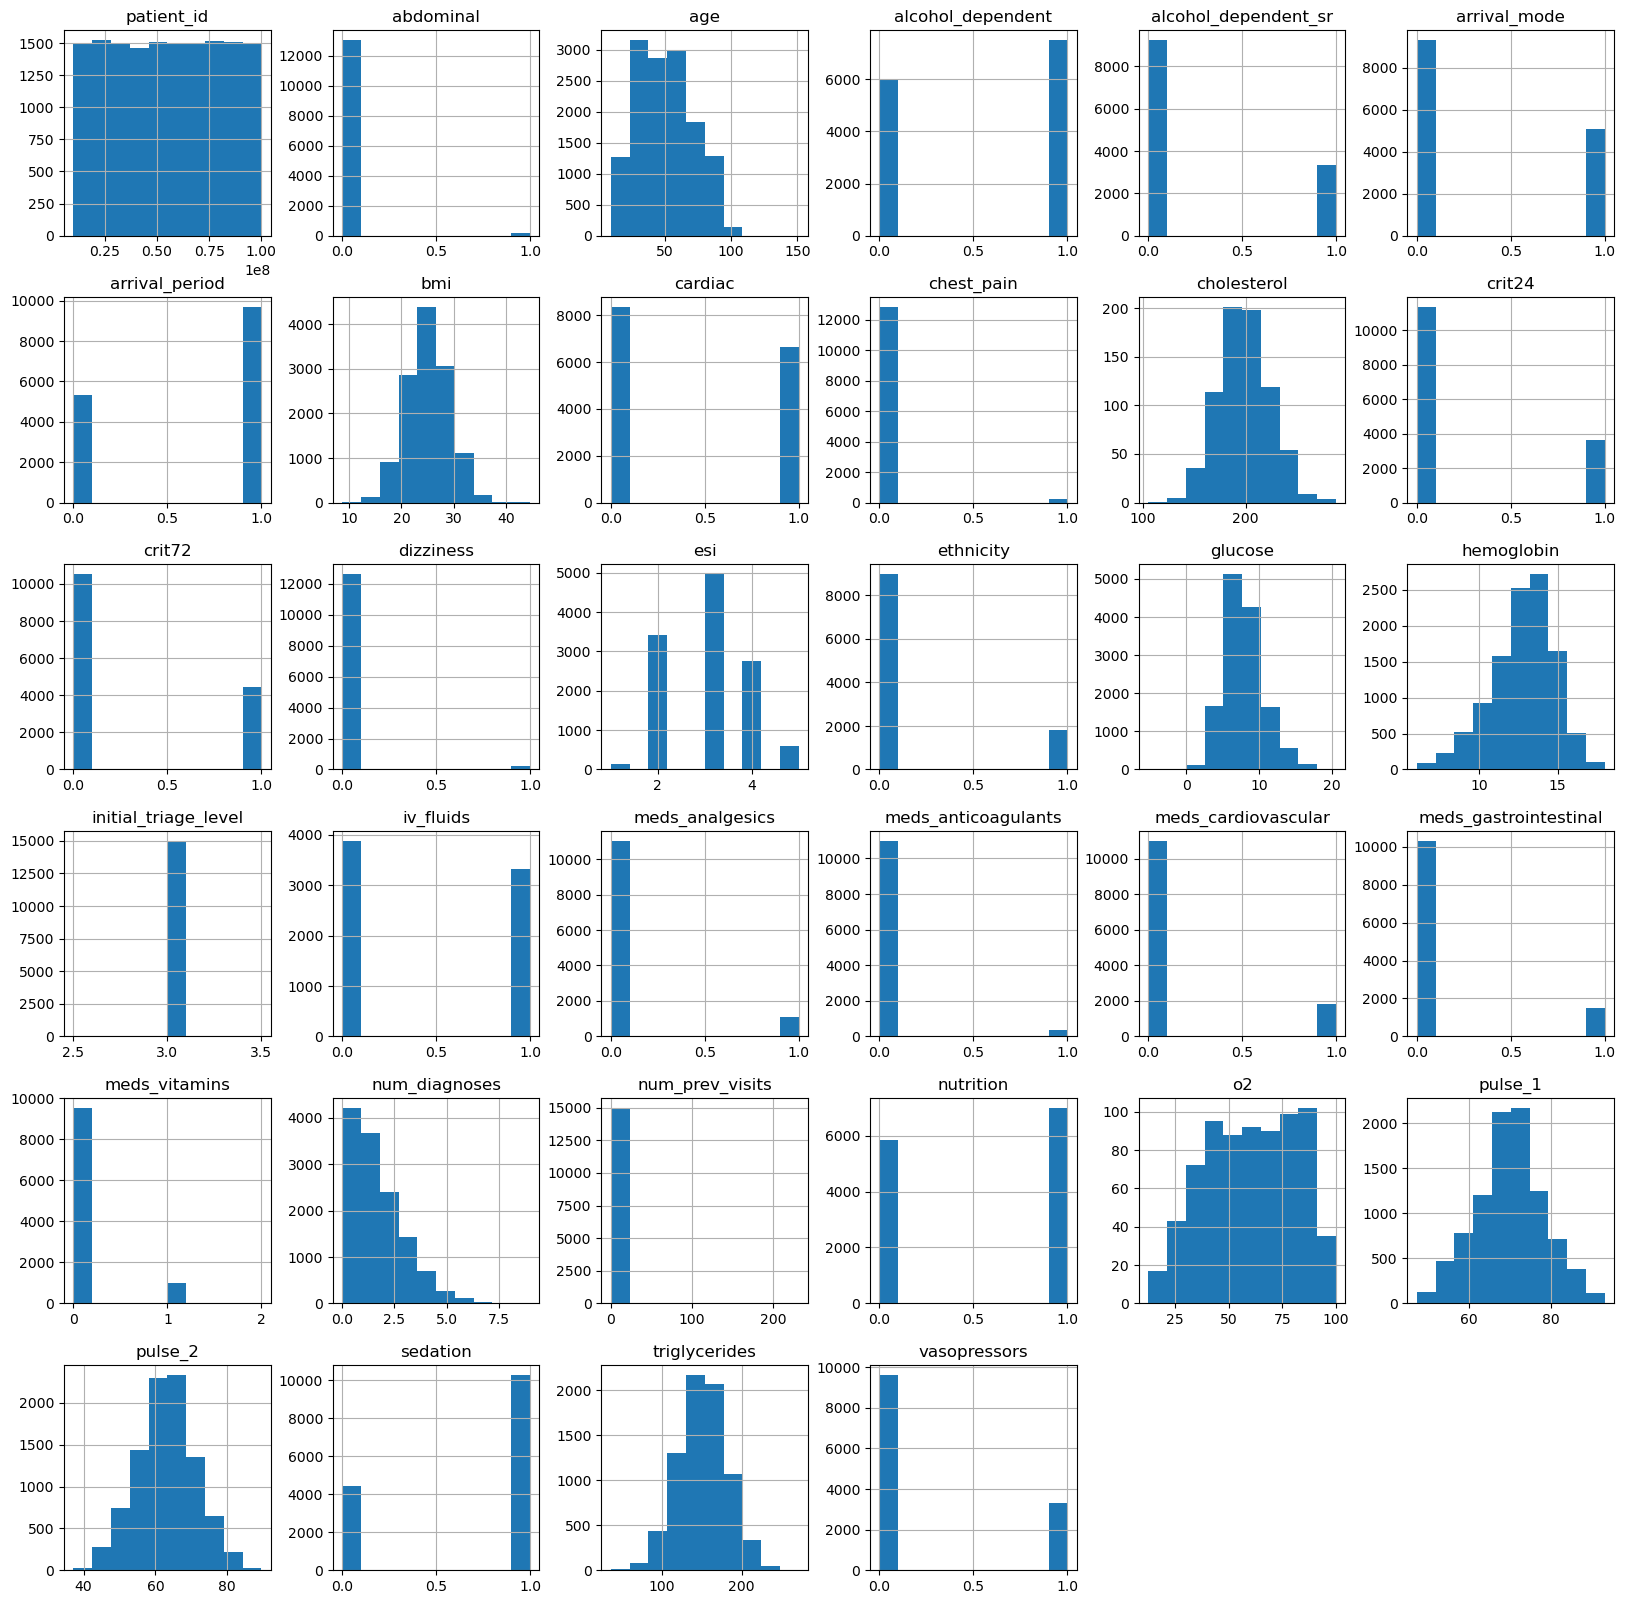

In [7]:
# plotting histogram distributions of every column

train.hist(figsize=(20,20))


We can see that crit72 is heavily skewed towards 0/no critical event, so will need to try oversampling or undersampling and report balanced accuracy.

The num_prev_visits column might also have weird outliers, and glucose might have negative values, looking at the scale of the histograms.

In [8]:
# summary statistics of num_prev_visits
train['num_prev_visits'].describe()

count    14996.000000
mean         5.065884
std          3.552257
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max        231.000000
Name: num_prev_visits, dtype: float64

<Axes: >

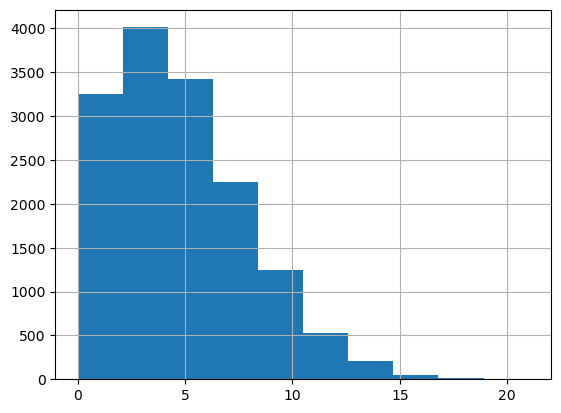

In [9]:
# distribution of num_prev_visits without outliers
train[train['num_prev_visits'] < 25]['num_prev_visits'].hist()

In [10]:
# summary statistics of glucose
train['glucose'].describe()

count    13525.000000
mean         7.879439
std          2.701024
min         -5.213200
25%          6.029446
50%          7.586152
75%          9.405484
max         20.512638
Name: glucose, dtype: float64

In [11]:
# viewing gender distribution
train['gender'].value_counts()

gender
Female    8200
Male      3326
male      3315
Other      157
Name: count, dtype: int64

In [12]:
# checking summary statistics of age
train['age'].describe()

count    13525.000000
mean        50.211386
std         20.388878
min          9.000000
25%         33.000000
50%         49.000000
75%         65.000000
max        151.000000
Name: age, dtype: float64

In [13]:
# the model is only meant to predict adult patients, so will need to remove patients under 18 years old from the training data
train = train[train['age'] >= 18]

Gender will need one-hot encoding

There are negative values of glucose which is impossible so will add a function to replace negative values with NaN

In [14]:
# separating the target variable from the features
# will do a train test split into x_train, y_train, and x_cal, y_cal, as we already have a separate test set
# won't train test split into x_val or y_val, as will use cross validation instead 

y = train['crit72']
X = train.drop(columns=['crit72'])

from sklearn.model_selection import train_test_split
X_train, X_cal, y_train, y_cal = train_test_split(X, y, test_size=0.2, random_state=1)

## Preprocessing Functions

In [75]:
# selecting features to remove
# some features have a lot of missing values, so we will remove them - cholesterol and o2
# from looking at the data dictionary, can see that other features could introduce temporal leakage, so we will remove them as well
# the model needs to be usable on admission - crit24, iv_fluids, sedation, vasopressors, pulse_2, and nutrition are all features assessed in the AMU so will cause temporal leakage
# initial_triage_level also doesn't look helpful as every data point is 3
# looking at the distributions of alchol_dependent vs alcohol_dependent_sr, it looks like there is some bias in self-reporting compared to a professional clinicians AUDIT assessment, which could just add noise, so will remove this too
def remove_features(X):
    X = X.copy()
    X = X.drop(columns=['patient_id', 'cholesterol', 'o2', 'crit24', 'iv_fluids', 'sedation', 'vasopressors', 'pulse_2', 'nutrition', 'initial_triage_level', 'alcohol_dependent_sr'],
                    errors='ignore')
    return X

# this function will go in the preprocessing pipeline so it can be applied to the unseen test data as well
from sklearn.preprocessing import FunctionTransformer
column_dropper = FunctionTransformer(remove_features)

In [16]:
# creating a function to convert num_prev_visits values of 25 or more to NA as they are likely to be outliers or errors
def remove_num_prev_visits_outliers(X):
    X = X.copy()
    X['num_prev_visits'] = X['num_prev_visits'].where(X['num_prev_visits'] < 25, np.nan)
    return X

remove_previous_visit_outliers = FunctionTransformer(remove_num_prev_visits_outliers)

In [17]:
# function to convert negative glucose values to NA as they are likely to be errors
def remove_negative_glucose(X):
    X = X.copy()
    X['glucose'] = X['glucose'].where(X['glucose'] >= 0, np.nan)
    return X

negative_glucose_dropper = FunctionTransformer(remove_negative_glucose)

The multimorbidity feature uses a cut-off of >= 2, in line with clinical definitions

Multimorbidity, Skou et al.
https://pmc.ncbi.nlm.nih.gov/articles/PMC7613517/

In [18]:
# function to convert num_diagnoses into a binary feature for multimorbidity
# 1 = multimorbidity, 0 = no multimorbidity
def convert_num_diagnoses_to_multimorbidity(X):
    X = X.copy()
    X['multimorbidity'] = (X['num_diagnoses'] >= 2).astype(int)
    X = X.drop(columns=['num_diagnoses'])
    return X

multimorbidity_transformer = FunctionTransformer(convert_num_diagnoses_to_multimorbidity)

In [19]:
# sample size consideration for multimorbidity - checking both groups will be well represented in the training data
train['multimorbidity'] = (train['num_diagnoses'] >= 2).astype(int)
train['multimorbidity'].value_counts()
train['multimorbidity'].value_counts(normalize=True)

multimorbidity
0    0.633015
1    0.366985
Name: proportion, dtype: float64

## Preprocessing Pipelines

In [20]:
# defining numeric and categorical columns for imputation
numeric_cols = ['age', 'bmi', 'esi', 'glucose', 'hemoglobin', 'num_prev_visits', 'pulse_1', 'triglycerides']

binary_cols = ['abdominal', 'alcohol_dependent', 'arrival_mode', 'arrival_period', 'cardiac', 'chest_pain', 'dizziness', 'ethnicity', 'meds_analgesics', 'meds_anticoagulants',
                    'meds_cardiovascular', 'meds_gastrointestinal', 'meds_vitamins']

# gender needs one hot encoding but this needs to be done in a separate pipeline to the already binary features
categorical_cols = ['gender']

In [21]:
# numeric imputer and categorical imputer
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# when handling missing data, will assume it is missing at random, and impute it 
# MAR assumes the missingness is related to other observed features, so SimpleImputer might not be ideal - could use KNNImputer

numeric_pipeline = make_pipeline(
    KNNImputer(n_neighbors=5),
    StandardScaler()
)

binary_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent')
)

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_cols),
        ('bin', binary_pipeline, binary_cols),
        ('num', numeric_pipeline, numeric_cols)
    ]
)

In [76]:
# setting the output of transformations to be pandas dataframes
# this will ensure that after imputation/scaling, the output is still a pandas dataframe
from sklearn import set_config
set_config(transform_output="pandas") 
   
preprocessing_pipeline = make_pipeline(
    column_dropper,
    remove_previous_visit_outliers,
    negative_glucose_dropper,
    multimorbidity_transformer,
    preprocessor
)
    

## Ensemble Model Pipelines

### Random Forest Classifier

In [49]:
# creating random forest classifier pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = make_pipeline(
    preprocessing_pipeline,
    RandomForestClassifier(class_weight='balanced', random_state=1)
)

In [ ]:
# defining the 5 cross validated folds for consistent reproducible evaluation across models
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# evaluating cross validated balanced accuracy of default random forest model
from sklearn.model_selection import cross_val_score
balanced_accuracy_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores:", balanced_accuracy_scores)
print("Mean balanced accuracy:", balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores: [0.63521539 0.62675491 0.62627233 0.65506787 0.64315041]
Mean balanced accuracy: 0.6372921822949528


In [52]:
# optimisation of random forest hyperparameters using randomised grid search with cross validation
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(rf_pipeline, param_distributions, n_iter=10, cv=cv, scoring='balanced_accuracy', random_state=1)
rf_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('functiontransformer-1',
                                                               FunctionTransformer(func=<function remove_features at 0x00000202BD7BF880>)),
                                                              ('functiontransformer-2',
                                                               FunctionTransformer(func=<function remove_num_prev_visits_outliers at 0x00000202BD7BED40>)),
                                                              ('func...
                                             ('randomforestclassifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=1))]),
                   param_distributions={'randomforestclassifier__max_depth': [None,
                                                                              10,
                                                                              20,
                                                                              30],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'randomforestclassifier__n_estimators': [100,
                                                                                 200,
                                                                                 300]},
                   random_state=1, scoring='balanced_accuracy')

In [54]:
# evaluating balanced accuracy of the best random forest model from the randomised grid search
best_rf_model = rf_random_search.best_estimator_
best_rf_balanced_accuracy_scores = cross_val_score(best_rf_model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores for best random forest model:", best_rf_balanced_accuracy_scores)
print("Mean balanced accuracy for best random forest model:", best_rf_balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores for best random forest model: [0.71229661 0.69351962 0.69257131 0.73196679 0.68539847]
Mean balanced accuracy for best random forest model: 0.70315056198918


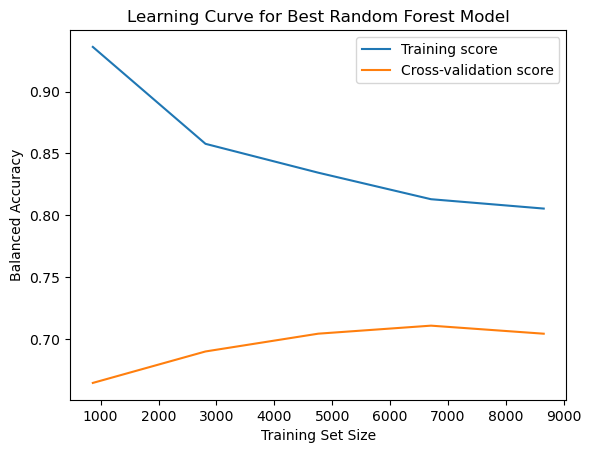

In [55]:
# printing learning curve for the best random forest model to check for overfitting or underfitting
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(best_rf_model, X_train, y_train, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure()
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curve for Best Random Forest Model')
plt.legend()
plt.show()

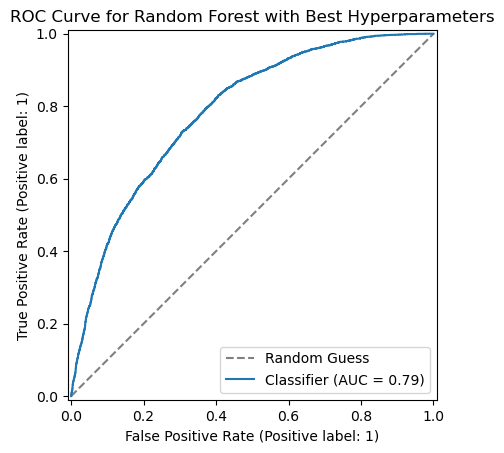

In [ ]:
# creating roc curve for the best random forest model
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_predict

fig, ax = plt.subplots()

# plotting the ROC-AUC curves for the best random forest model and a random guess line
ax.plot([0, 1], [0, 1], linestyle='--', label='Random Guess', color = 'grey')

# getting the predicted probabilities for the training data using cross_val_predict with method='predict_proba' to avoid overfitting
y_train_proba_rf = cross_val_predict(best_rf_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

RocCurveDisplay.from_predictions(y_train, y_train_proba_rf, ax=ax)
ax.set_title('ROC Curve for Random Forest with Best Hyperparameters')
plt.show()

              precision    recall  f1-score   support

           0       0.84      0.74      0.79      7590
           1       0.52      0.67      0.59      3226

    accuracy                           0.72     10816
   macro avg       0.68      0.70      0.69     10816
weighted avg       0.74      0.72      0.73     10816



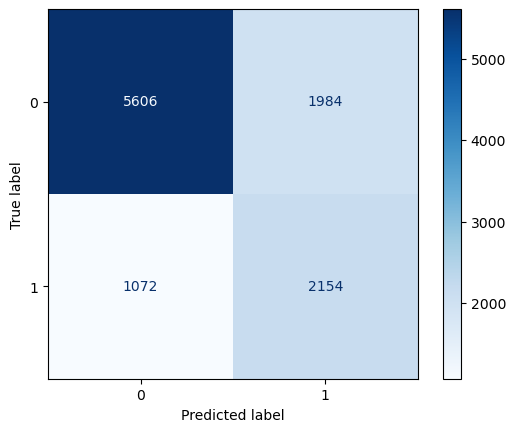

In [57]:
# creating classification report for the random forest with the best hyperparameters
from sklearn.metrics import classification_report

# using cross_val_predict with method='predict' to get the predicted classes for the training data without overfitting
y_train_pred = cross_val_predict(best_rf_model, X_train, y_train, cv=cv, method='predict')
print(classification_report(y_train, y_train_pred))

# creating confusion matrix for the random forest with the best hyperparameters
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')

### Gradient Boosting Classifier

In [58]:
# creating gradient boosting classifier pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = make_pipeline(
    preprocessing_pipeline,
    GradientBoostingClassifier(random_state=1)
)

In [59]:
# evaluating cross validated balanced accuracy of default gradient boosting model
gb_balanced_accuracy_scores = cross_val_score(gb_pipeline, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores for default gradient boosting model:", gb_balanced_accuracy_scores)
print("Mean balanced accuracy for default gradient boosting model:", gb_balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores for default gradient boosting model: [0.67482063 0.65179398 0.66249349 0.68045623 0.66154211]
Mean balanced accuracy for default gradient boosting model: 0.6662212871466989


In [60]:
# optimisation of gradient boosting hyperparameters using randomised grid search with cross validation
param_distributions_gb = {
    'gradientboostingclassifier__n_estimators': [100, 200, 300],
    'gradientboostingclassifier__learning_rate': [0.01, 0.05, 0.1],
    'gradientboostingclassifier__max_depth': [1, 2, 3],
    'gradientboostingclassifier__min_samples_split': [5, 10, 15],
    'gradientboostingclassifier__min_samples_leaf': [1, 2, 4]
}

gb_random_search = RandomizedSearchCV(gb_pipeline, param_distributions_gb, n_iter=10, cv=cv, scoring='balanced_accuracy', random_state=1)
gb_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('functiontransformer-1',
                                                               FunctionTransformer(func=<function remove_features at 0x00000202BD7BF880>)),
                                                              ('functiontransformer-2',
                                                               FunctionTransformer(func=<function remove_num_prev_visits_outliers at 0x00000202BD7BED40>)),
                                                              ('func...
                                              GradientBoostingClassifier(random_state=1))]),
                   param_distributions={'gradientboostingclassifier__learning_rate': [0.01,
                                                                                      0.05,
                                                                                      0.1],
                                        'gradientboostingclassifier__max_depth': [1,
                                                                                  2,
                                                                                  3],
                                        'gradientboostingclassifier__min_samples_leaf': [1,
                                                                                         2,
                                                                                         4],
                                        'gradientboostingclassifier__min_samples_split': [5,
                                                                                          10,
                                                                                          15],
                                        'gradientboostingclassifier__n_estimators': [100,
                                                                                     200,
                                                                                     300]},
                   random_state=1, scoring='balanced_accuracy')

In [61]:
# evaluating balanced accuracy of the best gradient boosting model from the randomised grid search
best_gb_model = gb_random_search.best_estimator_
best_gb_balanced_accuracy_scores = cross_val_score(best_gb_model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores for best gradient boosting model:", best_gb_balanced_accuracy_scores)
print("Mean balanced accuracy for best gradient boosting model:", best_gb_balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores for best gradient boosting model: [0.68534347 0.66466281 0.65989827 0.68559304 0.66439317]
Mean balanced accuracy for best gradient boosting model: 0.6719781533447338


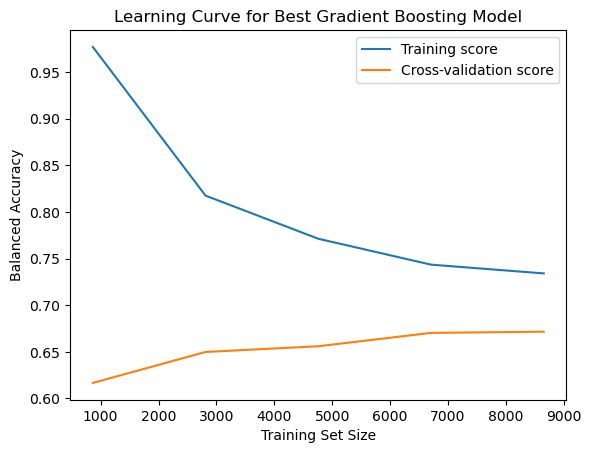

In [70]:
# printing learning curve for the best gradient boosting model to check for overfitting or underfitting
train_sizes_gb, train_scores_gb, test_scores_gb = learning_curve(best_gb_model, X_train, y_train, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
train_scores_gb_mean = np.mean(train_scores_gb, axis=1)
test_scores_gb_mean = np.mean(test_scores_gb, axis=1)
plt.figure()
plt.plot(train_sizes_gb, train_scores_gb_mean, label='Training score')
plt.plot(train_sizes_gb, test_scores_gb_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curve for Best Gradient Boosting Model')
plt.legend()
plt.show()

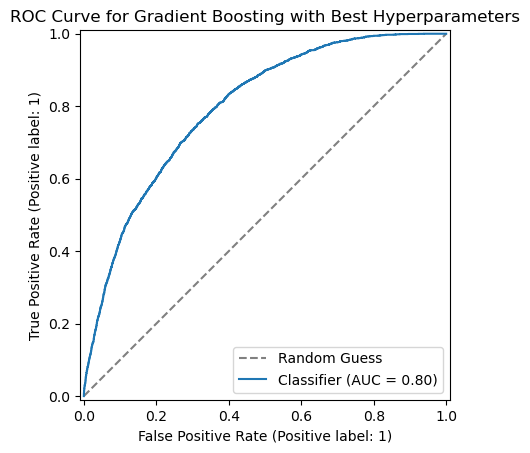

In [71]:
fig, ax = plt.subplots()

# plotting the ROC-AUC curves for the best gradient boosting model and a random guess line
ax.plot([0, 1], [0, 1], linestyle='--', label='Random Guess', color = 'grey')

# getting the predicted probabilities for the training data using cross_val_predict with method='predict_proba' to avoid overfitting
y_train_proba_gb = cross_val_predict(best_gb_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

RocCurveDisplay.from_predictions(y_train, y_train_proba_gb, ax=ax)
ax.set_title('ROC Curve for Gradient Boosting with Best Hyperparameters')
plt.show()

              precision    recall  f1-score   support

           0       0.79      0.89      0.84      7590
           1       0.64      0.45      0.53      3226

    accuracy                           0.76     10816
   macro avg       0.72      0.67      0.68     10816
weighted avg       0.75      0.76      0.75     10816



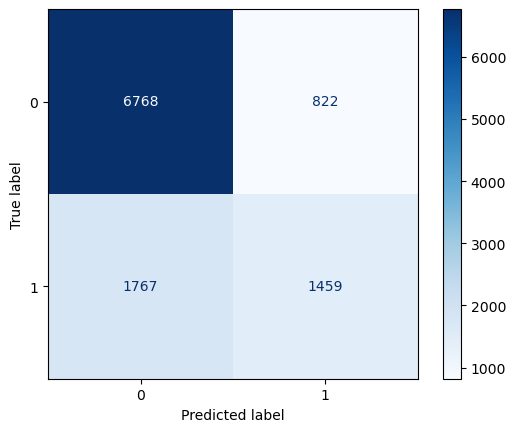

In [72]:
# creating classification report for the gradient boosting with the best hyperparameters
from sklearn.metrics import classification_report

# using cross_val_predict with method='predict' to get the predicted classes for the training data without overfitting
y_train_pred = cross_val_predict(best_gb_model, X_train, y_train, cv=cv, method='predict')
print(classification_report(y_train, y_train_pred))

# creating confusion matrix for the gradient boosting with the best hyperparameters
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')

### XGBoost Classifier

In [62]:
# creating xgboost classifier pipeline
import xgboost as xgb

# class imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_pipeline = make_pipeline(
    preprocessing_pipeline,
    xgb.XGBClassifier(random_state=1, eval_metric='logloss', scale_pos_weight=scale_pos_weight) 
)

In [63]:
# evaluating cross validated balanced accuracy of default xgboost model
xgb_balanced_accuracy_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores for default xgboost model:", xgb_balanced_accuracy_scores)
print("Mean balanced accuracy for default xgboost model:", xgb_balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores for default xgboost model: [0.69418271 0.69376628 0.68384502 0.70961945 0.67326501]
Mean balanced accuracy for default xgboost model: 0.690935692751612


In [64]:
# optimisation of xgboost hyperparameters using randomised grid search with cross validation
param_distributions_xgb = {
    'xgbclassifier__n_estimators': [50, 100, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2]
}

xgb_random_search = RandomizedSearchCV(xgb_pipeline, param_distributions_xgb, n_iter=10, cv=cv, scoring='balanced_accuracy', random_state=1)
xgb_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('functiontransformer-1',
                                                               FunctionTransformer(func=<function remove_features at 0x00000202BD7BF880>)),
                                                              ('functiontransformer-2',
                                                               FunctionTransformer(func=<function remove_num_prev_visits_outliers at 0x00000202BD7BED40>)),
                                                              ('func...
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   param_distributions={'xgbclassifier__learning_rate': [0.01,
                                                                         0.1,
                                                                         0.2],
                                        'xgbclassifier__max_depth': [3, 5, 7],
                                        'xgbclassifier__n_estimators': [50, 100,
                                                                        200]},
                   random_state=1, scoring='balanced_accuracy')

In [65]:
# evaluating balanced accuracy of the best xgboost model from the randomised grid search
best_xgb_model = xgb_random_search.best_estimator_
best_xgb_balanced_accuracy_scores = cross_val_score(best_xgb_model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("Cross-validated balanced accuracy scores for best xgboost model:", best_xgb_balanced_accuracy_scores)
print("Mean balanced accuracy for best xgboost model:", best_xgb_balanced_accuracy_scores.mean())

Cross-validated balanced accuracy scores for best xgboost model: [0.71489494 0.71343108 0.70709624 0.7358351  0.70277446]
Mean balanced accuracy for best xgboost model: 0.7148063628139196


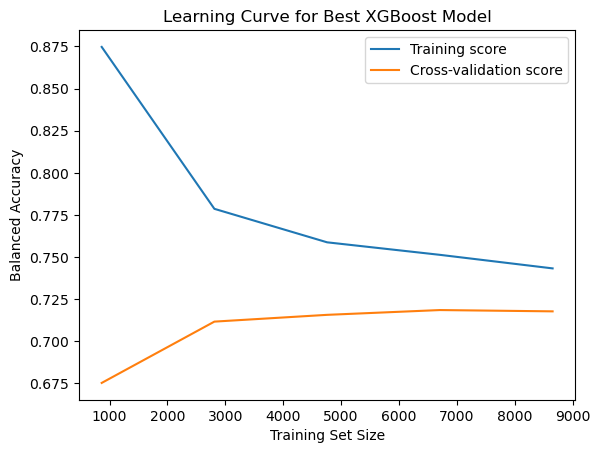

In [66]:
# printing learning curve for the best xgboost model to check for overfitting or underfitting
train_sizes_xgb, train_scores_xgb, test_scores_xgb = learning_curve(best_xgb_model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
train_scores_xgb_mean = np.mean(train_scores_xgb, axis=1)
test_scores_xgb_mean = np.mean(test_scores_xgb, axis=1)
plt.figure()
plt.plot(train_sizes_xgb, train_scores_xgb_mean, label='Training score')
plt.plot(train_sizes_xgb, test_scores_xgb_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curve for Best XGBoost Model')
plt.legend()
plt.show()

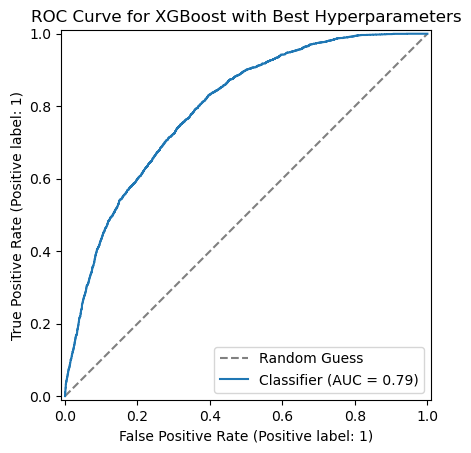

In [67]:
fig, ax = plt.subplots()

# plotting the ROC-AUC curves for the optimised xgboost model and a random guess line
ax.plot([0, 1], [0, 1], linestyle='--', label='Random Guess', color = 'grey')

# getting the predicted probabilities for the training data using cross_val_predict with method='predict_proba' to avoid overfitting
y_train_proba_xgb = cross_val_predict(best_xgb_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

RocCurveDisplay.from_predictions(y_train, y_train_proba_xgb, ax=ax)
ax.set_title('ROC Curve for XGBoost with Best Hyperparameters')
plt.show()

              precision    recall  f1-score   support

           0       0.88      0.65      0.74      7590
           1       0.48      0.78      0.60      3226

    accuracy                           0.69     10816
   macro avg       0.68      0.71      0.67     10816
weighted avg       0.76      0.69      0.70     10816



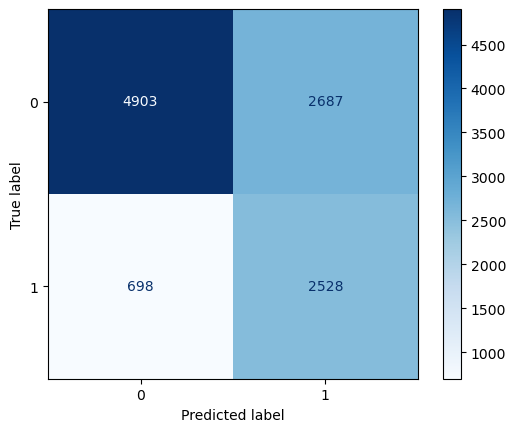

In [68]:
# creating classification report for the xgboost with the best hyperparameters
from sklearn.metrics import classification_report

# using cross_val_predict with method='predict' to get the predicted classes for the training data without overfitting
y_train_pred = cross_val_predict(best_xgb_model, X_train, y_train, cv=cv, method='predict')
print(classification_report(y_train, y_train_pred))

# creating confusion matrix for the xgboost with the best hyperparameters 
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')

There are far fewer false negatives predicted by the XGBoost model, which is clinically useful. Fewer patients who actually have a critical incident within 72 hours of admission will be discharged from the AMU, and clinicians can better prepare urgent treatment for them. The model is leaning towards sensitivity instead of specificity.

The XGBoost predicts more positives overall, however missing a patient in need of critical care is worse than potentially unnecessary monitoring.

### XGBoost Calibration

A stacked ensemble with the optimised Random Forest and XGBoost as base learners and Logistic Regression as a meta learner was tested, but did not achieve higher cross-validated balanced accuracy than XGBoost alone, so it was removed.

As the optimised XGBoost model had the highest balanced accuracy and the fewest false negatives, will move forward with this model.

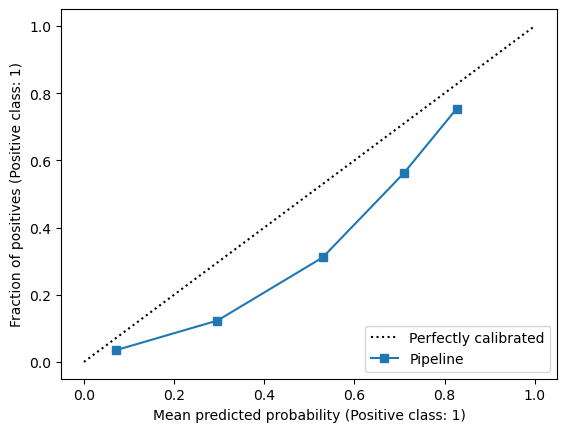

In [90]:
from sklearn.calibration import CalibrationDisplay
best_xgb_model.fit(X_train, y_train)
CalibrationDisplay.from_estimator(best_xgb_model, X_cal, y_cal)

In [91]:
# recalibrating the xgboost model using isotonic regression
from sklearn.calibration import CalibratedClassifierCV

calibrated_xgb = CalibratedClassifierCV(best_xgb_model, method='isotonic', cv='prefit')

# fit this to the calibration set to avoid overfitting
calibrated_xgb.fit(X_cal, y_cal)

c:\Users\willp\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('pipeline',
                                                  Pipeline(steps=[('functiontransformer-1',
                                                                   FunctionTransformer(func=<function remove_features at 0x00000202BD7BF880>)),
                                                                  ('functiontransformer-2',
                                                                   FunctionTransformer(func=<function remove_num_prev_visits_outliers at 0x00000202BD7BED40>)),
                                                                  ('functiontransformer-3',
                                                                   FunctionTransformer(func...
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.2,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=3,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=50,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]),
                       method='isotonic')

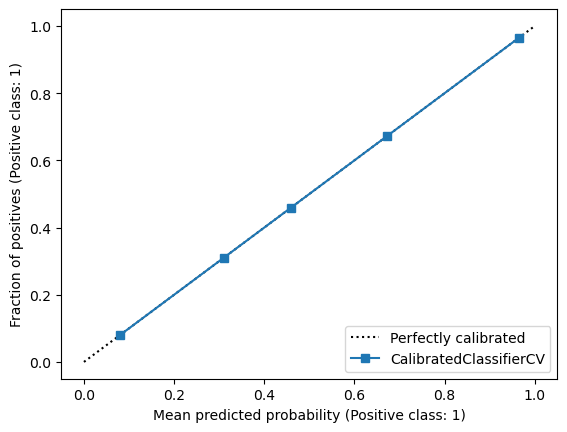

In [92]:
CalibrationDisplay.from_estimator(calibrated_xgb, X_cal, y_cal)

**You will not be able to run the code below as you do not have access to `y_test`**. 

In [ ]:
# do not run this code
y_test = pd.read_csv("y_test.csv")

balanced_accuracy = balanced_accuracy_score(y_true = y_test, y_pred = y_predict_ensemble)

print(f'Final balanced accuracy: {balanced_accuracy:.6f}')